# jl-sympy-hello: julia symbolic math demo

## SymPyPythonCall

- [SymPy documentation](https://docs.sympy.org/latest/index.html)
- [SymPy Features](https://docs.sympy.org/latest/tutorials/intro-tutorial/features.html)
- [SymPyPythonCall.jl](https://github.com/jverzani/SymPyPythonCall.jl)
- [SymPy.jl documentation](https://jverzani.github.io/SymPyCore.jl/dev/)


In [1]:
using SymPyPythonCall
using Plots

## Integral

In [2]:
@syms x y z t

(x, y, z, t)

In [3]:
f = exp(-x^2 - y^2)
F = (f, (x, -oo, oo), (y, -oo, oo))

(exp(-x^2 - y^2), (x, -oo, oo), (y, -oo, oo))

In [4]:
sympy.Integral(F...)

∞  ∞                  
⌠  ⌠                  
⎮  ⎮      2    2      
⎮  ⎮   - x  - y       
⎮  ⎮  ℯ          dx dy
⌡  ⌡                  
-∞ -∞                 

In [5]:
integrate(F...)

π

## Derivative

In [6]:
g = sin(x) / x

sin(x)
──────
  x   

In [7]:
dg = diff(g, x)

cos(x)   sin(x)
────── - ──────
  x         2  
           x   

In [8]:
g

sin(x)
──────
  x   

In [9]:
dg

cos(x)   sin(x)
────── - ──────
  x         2  
           x   

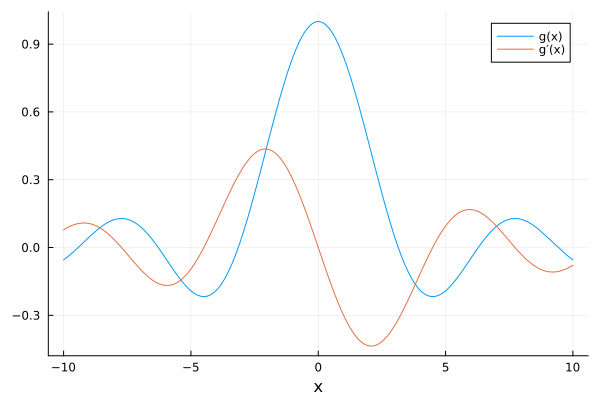

In [10]:
gf, dgf = lambdify(g), lambdify(dg)
plot([gf, dgf], -10, 10; label = ["g(x)" "g′(x)"], xlabel = "x")

## Differential Equation (ODE)

In [11]:
@syms y()
eq = diff(y(x), x, 2) + 9y(x)
Eq(eq, 0)

          2           
         d            
9⋅y(x) + ───(y(x)) = 0
           2          
         dx           

In [12]:
sol = dsolve(eq, y(x))
sol

y(x) = C₁⋅sin(3⋅x) + C₂⋅cos(3⋅x)

In [14]:
sympy.checkodesol(eq, sol)

(True, 0)

## Appendix: sympy-plot-backends (`spb`) via PythonCall

The Python demo plots with `spb.plot`. To use that backend directly instead of
`Plots.jl`, import it through `PythonCall` (the Python module must be installed
in the uv virtualenv that `PythonCall` points to):

```julia
using PythonCall
spb = pyimport("spb")
spb.plot(g, dg)
```